# Lab 4: RNN vs LSTM vs GRU
## Objective:
Compare performance of Simple RNN, LSTM, and GRU models.

In [1]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense

In [2]:
# Create Dummy Dataset (Time Series)
X = np.random.rand(1000, 10, 1)
y = np.sum(X, axis=1)

In [3]:
# Function to build models
def build_model(model_type):
    model = Sequential()
    if model_type == 'RNN':
        model.add(SimpleRNN(32, input_shape=(10,1)))
    elif model_type == 'LSTM':
        model.add(LSTM(32, input_shape=(10,1)))
    elif model_type == 'GRU':
        model.add(GRU(32, input_shape=(10,1)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

In [4]:
# Train models
histories = {}
models = ['RNN','LSTM','GRU']

for m in models:
    print(f"Training {m}...")
    model = build_model(m)
    history = model.fit(X, y, epochs=5, batch_size=32, verbose=1)
    histories[m] = history.history['loss']

Training RNN...


C:\Users\nikhi\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 16.9651
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.0588
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9157
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7451
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6269
Training LSTM...
Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 20.8002
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.8375
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6934
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5945
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5228
Training GRU...
Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 22.7559
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.5636 
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7475
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5136
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4685


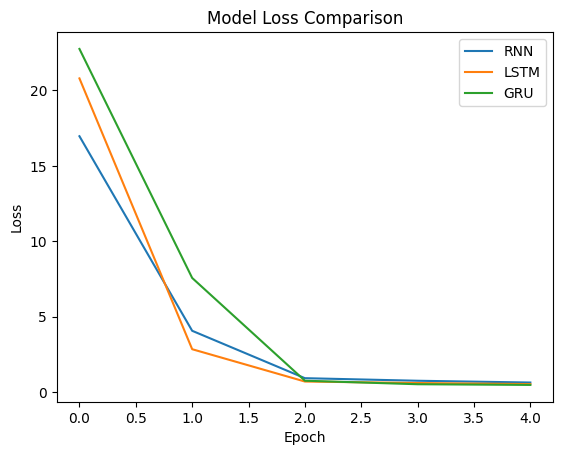

In [5]:
# Plot Comparison
for m in models:
    plt.plot(histories[m])

plt.title('Model Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(models)
plt.show()

## Conclusion:
- RNN is faster but less accurate
- LSTM gives best performance
- GRU is a balance between speed and accuracy